In [0]:
storage_account_name = "azuredatalake60304739"
storage_account_key = "zf3AijtocsoHcIdj5xqRmO6PAh9Fsen/D21XM9jGKAbdlZvLRJAqhciOkVnHCrxdRGItucPn6IcX+ASt4zabmw=="
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
gold_path = f"abfss://curated@azuredatalake60304739.dfs.core.windows.net/features_v1/"
df = spark.read.parquet(gold_path)

In [0]:
# Number of rows
n_rows = df.count()

# Number of columns
n_cols = len(df.columns)

print("Rows:", n_rows)
print("Columns:", n_cols)

# Schema 
df.printSchema()

Rows: 26998832
Columns: 11
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



In [0]:
print("Has reviewText:", "reviewText" in df.columns)
print("Has overall:", "overall" in df.columns)
print("Has asin:", "asin" in df.columns)
print("Has reviewerID:", "reviewerID" in df.columns)

print("dtypes:", dict(df.dtypes))  

Has reviewText: True
Has overall: True
Has asin: True
Has reviewerID: True
dtypes: {'asin': 'string', 'title': 'string', 'brand': 'string', 'price': 'double', 'reviewerID': 'string', 'overall': 'double', 'summary': 'string', 'reviewText': 'string', 'helpful': 'array<int>', 'reviewTime': 'string', 'review_year': 'int'}


In [0]:
from pyspark.sql.functions import col, trim, when, count

display(
    df.select(
        count(when(col("reviewText").isNull(), 1)).alias("reviewText"),
        count(when(trim(col("reviewText")) == "", 1)).alias("reviewText"),
        count(when(col("overall").isNull(), 1)).alias("overall"),
    )
)

reviewText,reviewText,overall
0,0,0


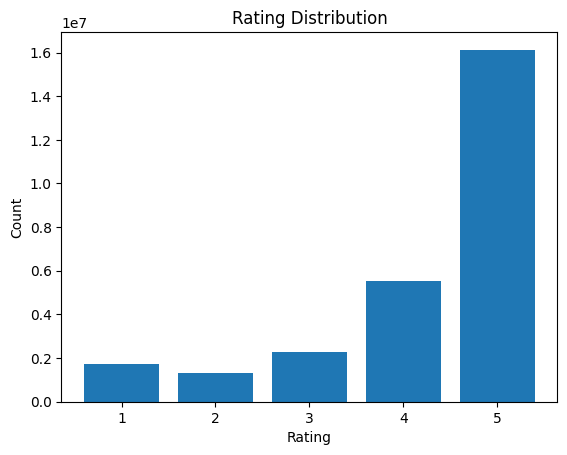

In [0]:
import matplotlib.pyplot as plt

rating_counts = df.groupBy("overall").count().orderBy("overall").toPandas()

plt.figure()
plt.bar(rating_counts["overall"], rating_counts["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

The rating distribution plot shows that the dataset is heavily skewed toward higher ratings, with 5-star reviews being the most frequent. Lower ratings such as 1 and 2 stars appear much less often, indicating class imbalance in the data. This imbalance is important for feature engineering because a model trained on this dataset may become biased toward predicting high ratings. It may require techniques such as class weighting, resampling, or the use of more appropriate evaluation metrics to ensure fair performance across all classes.


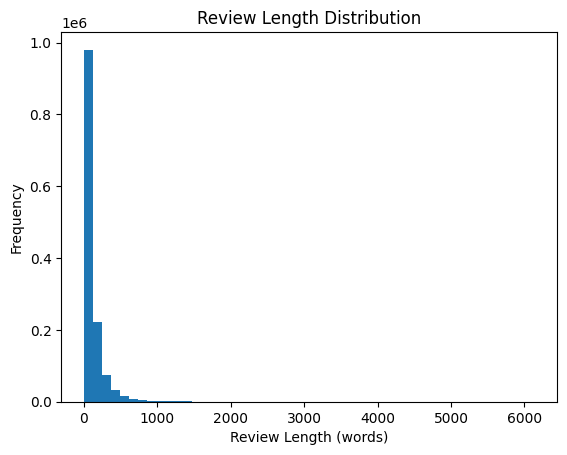

In [0]:
from pyspark.sql.functions import split, size, col

df_len = df.withColumn("review_len_words", size(split(col("reviewText"), r"\s+")))

length_sample = df_len.select("review_len_words").sample(False, 0.05).toPandas()

plt.figure()
plt.hist(length_sample["review_len_words"], bins=50)
plt.xlabel("Review Length (words)")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

The review length distribution shows that most reviews are relatively short, while a small number of reviews are extremely long. The distribution is right-skewed, meaning a few outliers significantly increase the maximum review length. This variation in length is important for feature engineering because it affects tokenization, memory usage, and model input limits.

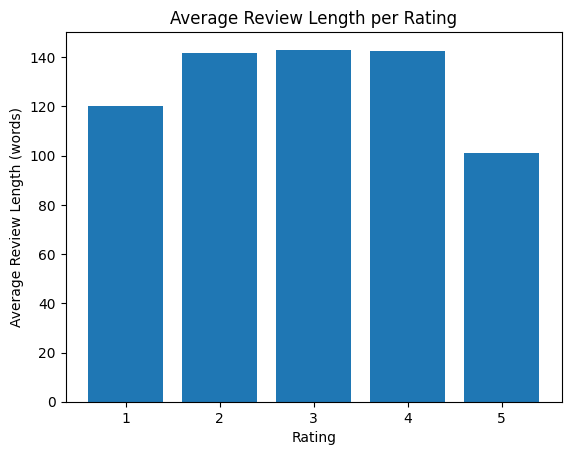

In [0]:
from pyspark.sql.functions import avg

df_len = df.withColumn(
    "review_len_words",
    size(split(col("reviewText"), r"\s+"))
)

avg_len_by_rating = (
    df_len.groupBy("overall")
          .agg(avg("review_len_words").alias("avg_review_length"))
          .orderBy("overall")
          .toPandas()
)

plt.figure()
plt.bar(avg_len_by_rating["overall"], avg_len_by_rating["avg_review_length"])
plt.xlabel("Rating")
plt.ylabel("Average Review Length (words)")
plt.title("Average Review Length per Rating")
plt.show()

The plot shows that average review length varies across rating categories. Reviews with ratings 2, 3, and 4 have the highest average word counts, while 5-star reviews are noticeably shorter on average. This suggests that users giving moderate ratings tend to write more detailed explanations, whereas very positive reviews may be shorter and more concise. This pattern is important for feature engineering because it indicates that review length may contain predictive information about sentiment or rating class.


In [0]:
sample_n = 300_000
sample_seed = 42
df_sampled = df.orderBy("reviewerID").limit(sample_n)
print("Sampled rows:", df_sampled.count())

Sampled rows: 300000


In [0]:
# Check schema matches original
df_sampled.printSchema()
# Compare rating distribution with original dataset
df.groupBy("overall").count().orderBy("overall").show()
df_sampled.groupBy("overall").count().orderBy("overall").show()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)

+-------+--------+
|overall|   count|
+-------+--------+
|    1.0| 1737792|
|    2.0| 1312896|
|    3.0| 2273696|
|    4.0| 5547088|
|    5.0|16127360|
+-------+--------+

+-------+------+
|overall| count|
+-------+------+
|    1.0| 19124|
|    2.0| 13600|
|    3.0| 25552|
|    4.0| 61309|
|    5.0|180415|
+-------+------+



In [0]:
# Number of rows
n_rows = df_sampled.count()

# Number of columns
n_cols = len(df_sampled.columns)

print("Rows:", n_rows)
print("Columns:", n_cols)

Rows: 300000
Columns: 11


In [0]:
sampled_gold_path = (
f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
"features_v1_sampled/"
)
df_sampled.write \
.mode("overwrite") \
.parquet(sampled_gold_path)